# Notebook 09: Out-of-distribution response (exploratory / SQ2 extension)

Exploratory analysis probing classifier over-confidence on unseen pathologies.

Evaluates whether K2N classifiers display appropriate uncertainty or unearned high confidence when presented with unseen pathologies (TB, COVID-19) from the Musa test cohort.

Limitations for Write-up:
- Musa dataset mixes paediatric and adult radiographs.
- Evaluates binary models (no dedicated output node for TB/COVID).
- Evaluated solely on the Musa test partition.

## 1. Setup

In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import config
from src import splits as SP
from src import datasets as DS
from src import models as M
from src import inference as INF
from src import metrics as MET
from src import results as RES

for mod in (config, SP, DS, M, INF, MET, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()
device = config.get_device()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Compute Device: GPU (Tesla T4)


In [6]:
print("--- Musa Test Set Image Availability ---")
missing_classes = []
for cls_name, cls_dir in config.MUSA_SPLITS["test"].items():
    img_list = SP.list_images(cls_dir)
    n_images = len(img_list)
    status = "ok" if n_images > 0 else "MISSING"
    print(f"  Musa test / {cls_name:12s}: {n_images:4d} images ({status})")
    if n_images == 0:
        missing_classes.append(cls_name)

if missing_classes:
    print(f"\nWarning: Missing classes {missing_classes}. OOD analysis requires all four Musa test partitions.")
else:
    print("\nAll four Musa test class partitions present and verified.")


--- Musa Test Set Image Availability ---
  Musa test / NORMAL      :  150 images (ok)
  Musa test / PNEUMONIA   :  150 images (ok)
  Musa test / TB          :  150 images (ok)
  Musa test / COVID       :  150 images (ok)

All four Musa test class partitions present and verified.


## 2. Construct In-Distribution and OOD Evaluation Datasets

In [7]:
eval_transforms = DS.build_transforms(
    config.IMAGE_SIZE,
    config.IMAGENET_MEAN,
    config.IMAGENET_STD,
    train=False
)

def build_musa_records_dataframe(target_classes):
    """Builds a DataFrame of image paths and mapped binary targets from Musa test splits."""
    records = []
    for cls_name in target_classes:
        split_dir = config.MUSA_SPLITS["test"][cls_name]
        for img_path in SP.list_images(split_dir):
            records.append({
                "path": str(img_path),
                "label": {"NORMAL": 0, "PNEUMONIA": 1}.get(cls_name, -1),
                "class": cls_name
            })
    return pd.DataFrame(records)

id_df = build_musa_records_dataframe(config.MUSA_ID_CLASSES)
ood_df = build_musa_records_dataframe(config.MUSA_OOD_CLASSES)

print(f"In-Distribution Dataset (NORMAL / PNEUMONIA): {len(id_df)} images")
print(f"Out-Of-Distribution Dataset (TB / COVID-19):    {len(ood_df)} images")

# Assign non-negative dummy label to OOD DataFrame for PyTorch Dataset compatibility
id_dataset = DS.CXRDataset(id_df.assign(label=id_df.label.clip(lower=0))[["path", "label"]], eval_transforms)
ood_dataset = DS.CXRDataset(ood_df.assign(label=0)[["path", "label"]], eval_transforms)


In-Distribution Dataset (NORMAL / PNEUMONIA): 300 images
Out-Of-Distribution Dataset (TB / COVID-19):    300 images


## 3. Probe K2N Model Checkpoints for OOD Confidence

In [8]:
k2n_checkpoints = sorted(config.CHECKPOINTS_DIR.glob("*__K2N__*.pth"))
print(f"Found {len(k2n_checkpoints)} K2N model checkpoints.")

conf_in_list = []
conf_ood_list = []
ood_prob_list = []
per_checkpoint_results = []

for ckpt_path in k2n_checkpoints:
    info = RES.parse_run_id(ckpt_path.stem)

    model = M.build_model(info["arch"], pretrained=False)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    # Run inference on ID and OOD sets
    id_output = INF.predict(model, id_dataset, device, batch_size=32, num_workers=2)
    ood_output = INF.predict(model, ood_dataset, device, batch_size=32, num_workers=2)

    # Calculate model confidence max(p, 1-p)
    conf_id = MET.confidence_score(id_output["y_prob"])
    conf_ood = MET.confidence_score(ood_output["y_prob"])

    conf_in_list.append(conf_id)
    conf_ood_list.append(conf_ood)
    ood_prob_list.append(ood_output["y_prob"])

    row_entry = {
        **{k: info[k] for k in ("arch", "size", "seed") if k in info},
        "mean_conf_in": round(float(conf_id.mean()), 3),
        "mean_conf_ood": round(float(conf_ood.mean()), 3),
        "ood_detect_auroc": round(float(MET.ood_detection_auroc(conf_id, conf_ood)), 3)
    }
    per_checkpoint_results.append(row_entry)

per_checkpoint_df = pd.DataFrame(per_checkpoint_results)
print("\n--- Per-Checkpoint OOD Response (K2N) ---")
print(per_checkpoint_df.to_string(index=False))

csv_out_path = config.RESULTS_DIR / "09_ood_per_checkpoint.csv"
per_checkpoint_df.to_csv(csv_out_path, index=False)
print(f"Saved per-checkpoint metrics to {csv_out_path.name}")


Found 36 K2N model checkpoints.

--- Per-Checkpoint OOD Response (K2N) ---
           arch  size  seed  mean_conf_in  mean_conf_ood  ood_detect_auroc
efficientnet_b0   100    42         0.846          0.862             0.473
efficientnet_b0   100    43         0.870          0.858             0.571
efficientnet_b0   100    44         0.888          0.892             0.543
efficientnet_b0   100    45         0.927          0.882             0.651
efficientnet_b0   100    46         0.919          0.829             0.696
efficientnet_b0   100    47         0.821          0.810             0.550
efficientnet_b0   190    42         0.839          0.856             0.484
efficientnet_b0   190    43         0.876          0.866             0.549
efficientnet_b0   190    44         0.885          0.882             0.529
efficientnet_b0   190    45         0.928          0.826             0.758
efficientnet_b0   190    46         0.944          0.859             0.734
efficientnet_b0   190    

## 4. Consolidated Pooled OOD Response Analysis

In [9]:
ci_pooled = np.concatenate(conf_in_list)
co_pooled = np.concatenate(conf_ood_list)
ood_detection_auroc = MET.ood_detection_auroc(ci_pooled, co_pooled)

print("\n--- Pooled K2N Out-of-Distribution Response ---")
print(f"  Mean Confidence (In-Distribution): {ci_pooled.mean():.3f}")
print(f"  Mean Confidence (Out-of-Distribution): {co_pooled.mean():.3f}")
print(f"  OOD-Detection AUROC:                {ood_detection_auroc:.3f}")

if ood_detection_auroc < 0.60:
    print("\n  Finding -> Model confidence fails to separate unseen pathologies from known classes.")
    print("             K2N classifiers are roughly as confident on unseen TB/COVID as on in-distribution data.")



--- Pooled K2N Out-of-Distribution Response ---
  Mean Confidence (In-Distribution): 0.882
  Mean Confidence (Out-of-Distribution): 0.882
  OOD-Detection AUROC:                0.516

  Finding -> Model confidence fails to separate unseen pathologies from known classes.
             K2N classifiers are roughly as confident on unseen TB/COVID as on in-distribution data.


In [10]:
ood_probs_pooled = np.concatenate(ood_prob_list)
pneu_fraction = float((ood_probs_pooled >= 0.5).mean())

print(f"\n  Unseen Pathology Predictions:")
print(f"    Classified as PNEUMONIA: {pneu_fraction:.1%}")
print(f"    Classified as NORMAL:    {1.0 - pneu_fraction:.1%}")



  Unseen Pathology Predictions:
    Classified as PNEUMONIA: 93.7%
    Classified as NORMAL:    6.3%


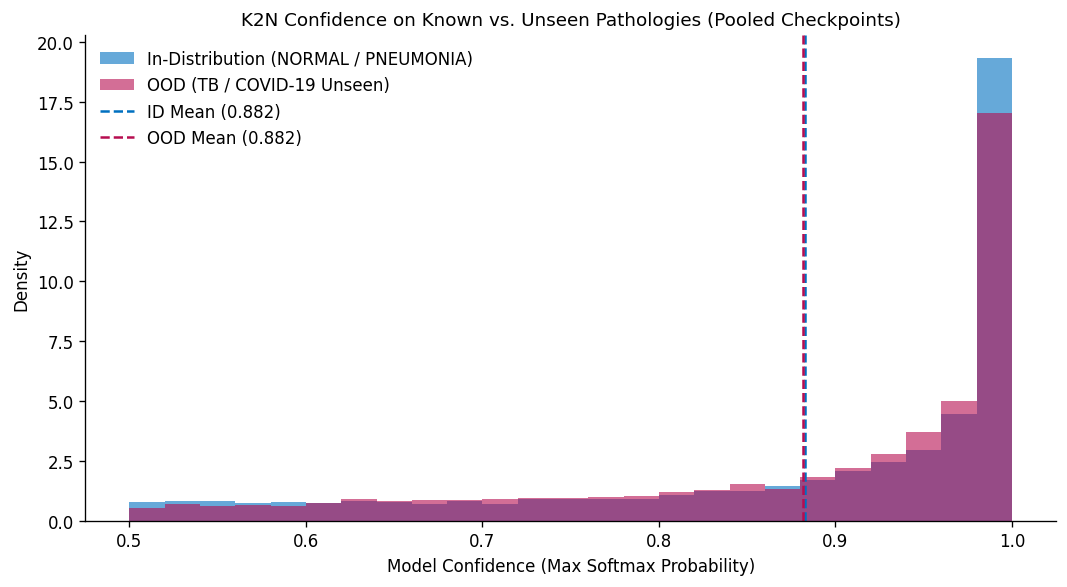

Saved figure to 09_ood_confidence.png


In [11]:
# Confidence Distribution Plot
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0.5, 1.0, 26)

ax.hist(
    ci_pooled,
    bins=bins,
    alpha=0.6,
    density=True,
    color=config.BRAND["C3"],
    label="In-Distribution (NORMAL / PNEUMONIA)"
)
ax.hist(
    co_pooled,
    bins=bins,
    alpha=0.6,
    density=True,
    color=config.BRAND["C1"],
    label="OOD (TB / COVID-19 Unseen)"
)

ax.axvline(ci_pooled.mean(), color=config.BRAND["C3"], linestyle="--", linewidth=1.5, label=f"ID Mean ({ci_pooled.mean():.3f})")
ax.axvline(co_pooled.mean(), color=config.BRAND["C1"], linestyle="--", linewidth=1.5, label=f"OOD Mean ({co_pooled.mean():.3f})")

ax.set_xlabel("Model Confidence (Max Softmax Probability)")
ax.set_ylabel("Density")
ax.set_title("K2N Confidence on Known vs. Unseen Pathologies (Pooled Checkpoints)")
ax.legend()
fig.tight_layout()

fig_out_path = config.FIGURES_DIR / "09_ood_confidence.png"
fig.savefig(fig_out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figure to {fig_out_path.name}")


**Next:** notebook 10 (aggregate).